In [11]:
!pip install -r requirements.txt

### Imports

In [50]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import learning_curve

## Logisitc Regression

### Loading Datasets

In [16]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

### Cleaning and Encoding Labels

In [ ]:
train["target"] = train["target"].astype(str).str.strip().str.lower()
test["target"] = test["target"].astype(str).str.strip().str.lower()

label_map = {"tennis": 0, "orange": 1}
train["target"] = train["target"].map(label_map)
test["target"] = test["target"].map(label_map)

### Dropping Anomalies

In [ ]:
train = train.dropna(subset=["target"]).copy()
test = test.dropna(subset=["target"]).copy()

train["target"] = train["target"].astype(int)
test["target"] = test["target"].astype(int)


### Feature Engineering

In [ ]:
def add_features(df):
    df = df.copy()
    df["gaze_tennis_dist"] = np.sqrt((df["gaze_x"] - df["tennis_x"])**2 + (df["gaze_y"] - df["tennis_y"])**2)
    df["gaze_orange_dist"] = np.sqrt((df["gaze_x"] - df["orange_x"])**2 + (df["gaze_y"] - df["orange_y"])**2)
    df["hand_tennis_dist"] = np.sqrt((df["hand_x"] - df["tennis_x"])**2 + (df["hand_y"] - df["tennis_y"])**2)
    df["hand_orange_dist"] = np.sqrt((df["hand_x"] - df["orange_x"])**2 + (df["hand_y"] - df["orange_y"])**2)
    return df

train = add_features(train)
test = add_features(test)

features = [
    "gaze_tennis_dist",
    "gaze_orange_dist",
    "hand_tennis_dist",
    "hand_orange_dist"
]

X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]

### Model

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Results

### These are the Metrics

In [46]:
print("Train class counts:\n", pd.Series(y_train).value_counts())
print("Test class counts:\n", pd.Series(y_test).value_counts())
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Coefficients:\n", model.coef_)


Train class counts:
 target
1    67
0    64
Name: count, dtype: int64
Test class counts:
 target
1    7
0    7
Name: count, dtype: int64
Accuracy: 0.643

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.57      0.62         7
           1       0.62      0.71      0.67         7

    accuracy                           0.64        14
   macro avg       0.65      0.64      0.64        14
weighted avg       0.65      0.64      0.64        14

Confusion Matrix:
 [[4 3]
 [2 5]]
Coefficients:
 [[ 1.70726065 -1.84935239  0.5664385  -0.51487969]]


### Confusion Matrix

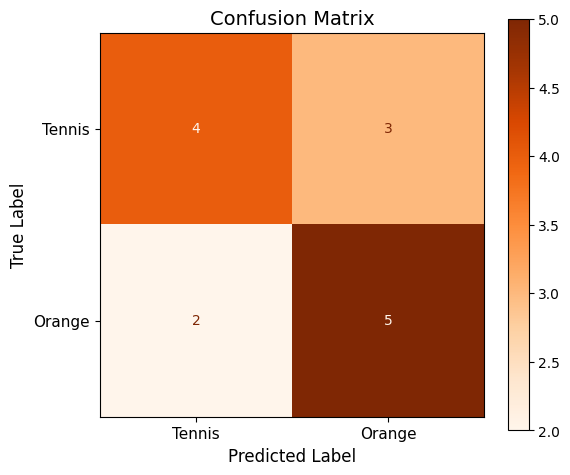

In [47]:
# --- Scientific-style Confusion Matrix ---
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,5))  # 👈 normal size

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Tennis", "Orange"]
)

disp.plot(
    ax=ax,
    cmap="Oranges",
    colorbar=True,
    values_format="d"
)

ax.set_title("Confusion Matrix", fontsize=14)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)

ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

### Model Learning Curve

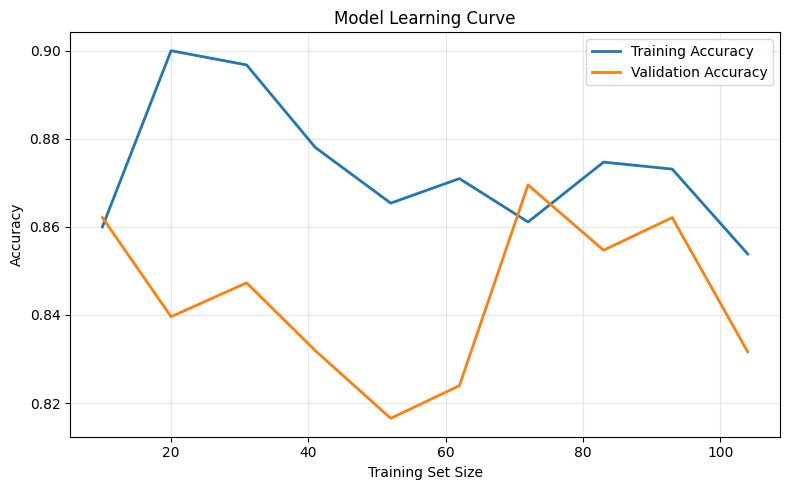

In [48]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(max_iter=200),
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, linewidth=2, label="Training Accuracy")
plt.plot(train_sizes, test_mean, linewidth=2, label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Model Learning Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


   frame  accuracy
0      0  0.388889
1     23  1.000000
2     46  0.944444
3     69  1.000000
4     92  1.000000
5    115  0.944444
6    138  0.705882
7    161  0.666667


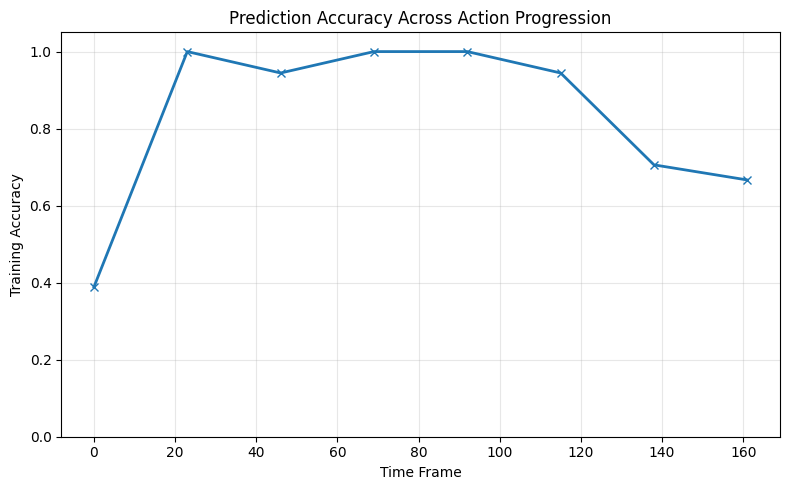

In [49]:
import pandas as pd
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Get training predictions
y_train_pred = model.predict(X_train)

train_results = train.copy()
train_results["y_true"] = y_train
train_results["y_pred"] = y_train_pred

frame_acc = (
    train_results.groupby("frame")
    .apply(lambda g: accuracy_score(g["y_true"], g["y_pred"]))
    .reset_index(name="accuracy")
)

print(frame_acc)

plt.figure(figsize=(8,5))
plt.plot(frame_acc["frame"], frame_acc["accuracy"], marker="x", linewidth=2)

plt.xlabel("Time Frame")
plt.ylabel("Training Accuracy")
plt.title("Prediction Accuracy Across Action Progression")

plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()